### Identificação

- **Nome**: João Pedro Simon Figueiró
- **Cartão UFRGS:** 5899908

In [254]:
import pandas as pd

tcg_df = pd.read_csv('/content/pokemon-tcg-data-master 1999-2023.csv')

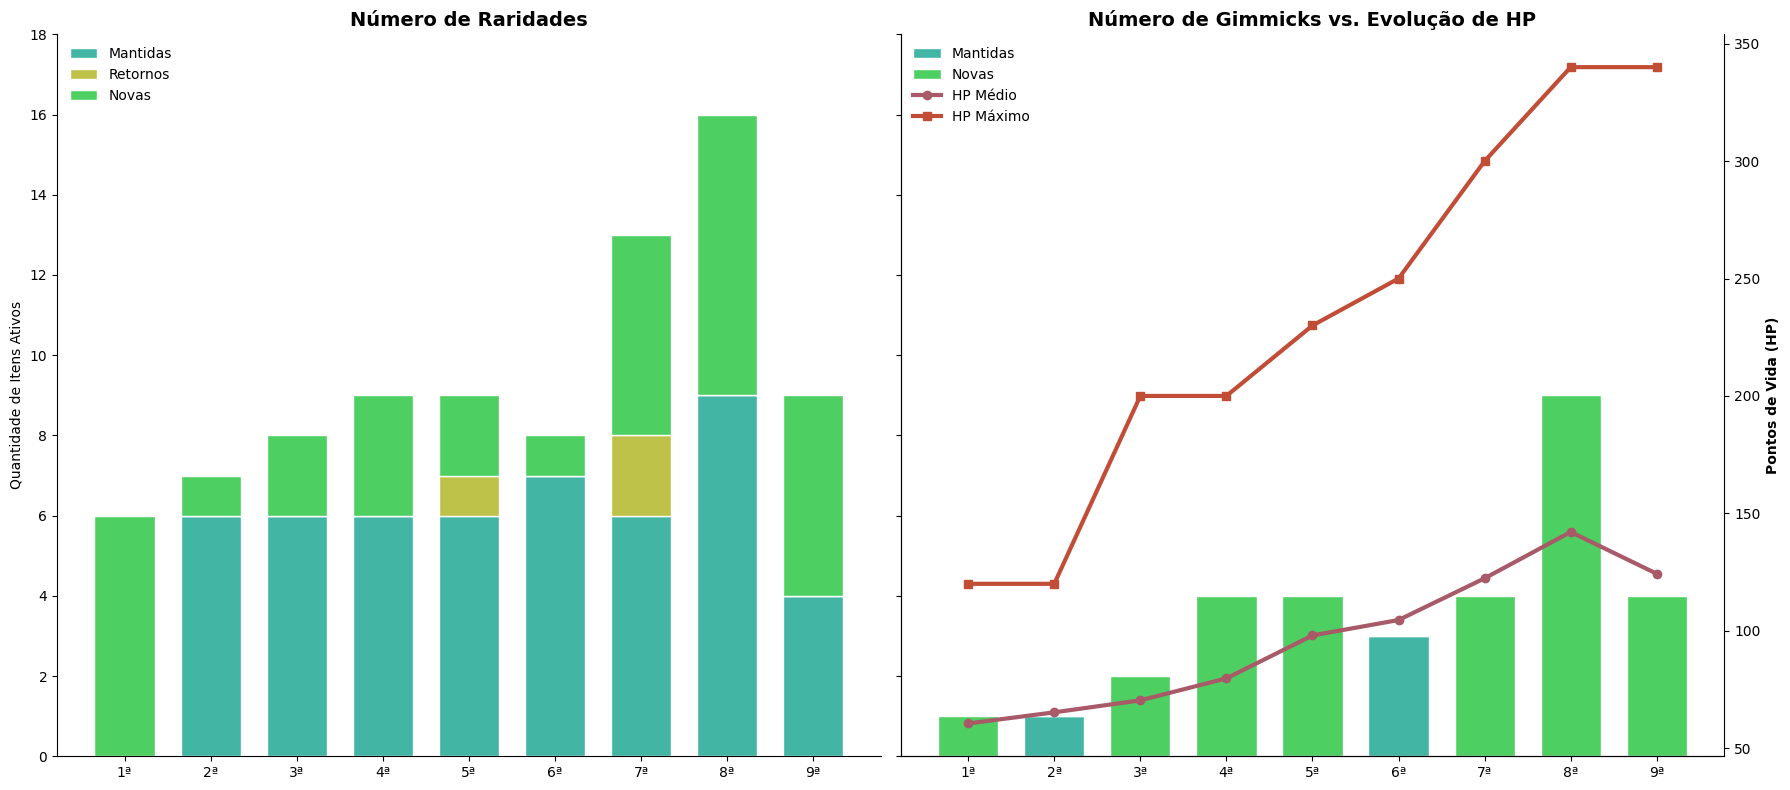

In [256]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np
import pandas as pd

# 1. Preparação
gen_map_pt = {'First': '1ª', 'Second': '2ª', 'Third': '3ª', 'Fourth': '4ª', 'Fifth': '5ª', 'Sixth': '6ª', 'Seventh': '7ª', 'Eighth': '8ª', 'Ninth': '9ª'}
gen_order = ['First', 'Second', 'Third', 'Fourth', 'Fifth', 'Sixth', 'Seventh', 'Eighth', 'Ninth']
gen_order_pt = [gen_map_pt[g] for g in gen_order]

data = tcg_df[tcg_df['generation'] != 'other'].copy()
data['generation'] = data['generation'].replace({'Fourth ': 'Fourth'})

# 2. Processamento de Fluxo
def get_flow_stats(item_map):
    stats = []
    historical = set()
    for i, gen in enumerate(gen_order):
        current = item_map[gen]
        prev = item_map[gen_order[i-1]] if i > 0 else set()
        legacy = len(current & prev)
        returned = len((current - prev) & historical)
        new = len(current - prev - historical)
        stats.append({'Legacy': legacy, 'Returned': returned, 'New': new})
        historical.update(current)
    return pd.DataFrame(stats)

rarity_map = {gen: set(data[(data['generation'] == gen) & (data['rarity'].notna())]['rarity'].unique()) for gen in gen_order}
gimmick_map = {gen: set() for gen in gen_order}
for name, s, e, total in gimmicks:
    start_idx, end_idx = gen_order.index(s), gen_order.index(e)
    for j in range(start_idx, end_idx + 1): gimmick_map[gen_order[j]].add(name)

df_rarity_flow = get_flow_stats(rarity_map)
df_gimmick_flow = get_flow_stats(gimmick_map)

# Médias e Máximos de HP
hp_valid = data[data['hp'].notna()]
hp_avg = hp_valid.groupby('generation')['hp'].mean().reindex(gen_order)
hp_max = hp_valid.groupby('generation')['hp'].max().reindex(gen_order)

# 3. Cores Atualizadas
C_STAY   = '#43B5A4'
C_RETURN = '#BFC248'
C_NEW    = '#4ECF61'
C_HP_AVG   = '#A85A68'
C_HP_MAX   = '#C24D37'

max_y = max(df_rarity_flow.sum(axis=1).max(), df_gimmick_flow.sum(axis=1).max()) + 2

# 4. Plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
x_pos = np.arange(len(gen_order))
width = 0.7

# Gráfico 1: Raridades (Com Retornos)
ax1.bar(x_pos, df_rarity_flow['Legacy'], width, label='Mantidas', color=C_STAY, edgecolor='white')
ax1.bar(x_pos, df_rarity_flow['Returned'], width, bottom=df_rarity_flow['Legacy'], label='Retornos', color=C_RETURN, edgecolor='white')
ax1.bar(x_pos, df_rarity_flow['New'], width, bottom=df_rarity_flow['Legacy'] + df_rarity_flow['Returned'], label='Novas', color=C_NEW, edgecolor='white')
ax1.set_title('Número de Raridades', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(gen_order_pt)
ax1.set_ylabel('Quantidade de Itens Ativos')
ax1.legend(frameon=False, loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)

# Gráfico 2: Gimmicks (Sem Retornos) + HP
ax2.bar(x_pos, df_gimmick_flow['Legacy'], width, label='Mantidas', color=C_STAY, edgecolor='white')
ax2.bar(x_pos, df_gimmick_flow['New'], width, bottom=df_gimmick_flow['Legacy'], label='Novas', color=C_NEW, edgecolor='white')
ax2.set_title('Número de Gimmicks vs. Evolução de HP', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(gen_order_pt)
ax2.set_ylim(0, max_y)
ax2.spines[['top', 'right']].set_visible(False)

# Eixo Secundário para HP
ax2_hp = ax2.twinx()
ax2_hp.plot(x_pos, hp_avg, color=C_HP_AVG, marker='o', linewidth=3, label='HP Médio')
ax2_hp.plot(x_pos, hp_max, color=C_HP_MAX, marker='s', linewidth=3, label='HP Máximo')
ax2_hp.set_ylabel('Pontos de Vida (HP)', fontweight='bold')
ax2_hp.spines['top'].set_visible(False)

# Legenda Consolidada para o Gráfico 2
h_g, l_g = ax2.get_legend_handles_labels()
h_h, l_h = ax2_hp.get_legend_handles_labels()
ax2.legend(h_g + h_h, l_g + l_h, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()